In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [22]:
df=pd.read_csv(r"C:\Users\Kirti\Desktop\Global Supply Chain Performance\data\clean_supply_chain.csv",low_memory=False)

In [23]:
df.head(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Order Year,Order Month,Day Name,Delivery Days,Delayed,Profit Margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0,2018-03-02,Standard Class,2018,1,Wednesday,30.0,0,27.841342
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,327.75,0,2018-01-18,Standard Class,2018,1,Saturday,5.0,1,-75.999999
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,327.75,0,2018-01-17,Standard Class,2018,1,Saturday,4.0,0,-75.600305


In [24]:
df.shape

(161365, 57)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161365 entries, 0 to 161364
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           161365 non-null  object 
 1   Days for shipping (real)       161365 non-null  int64  
 2   Days for shipment (scheduled)  161365 non-null  int64  
 3   Benefit per order              161365 non-null  float64
 4   Sales per customer             161365 non-null  float64
 5   Delivery Status                161365 non-null  object 
 6   Late_delivery_risk             161365 non-null  int64  
 7   Category Id                    161365 non-null  int64  
 8   Category Name                  161365 non-null  object 
 9   Customer City                  161365 non-null  object 
 10  Customer Country               161365 non-null  object 
 11  Customer Email                 161365 non-null  object 
 12  Customer Fname                

In [26]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Image',
       'Product Na

In [27]:
df['Delivery Status'].value_counts()

Delivery Status
Late delivery        88670
Advance shipping     36994
Shipping on time     28926
Shipping canceled     6775
Name: count, dtype: int64

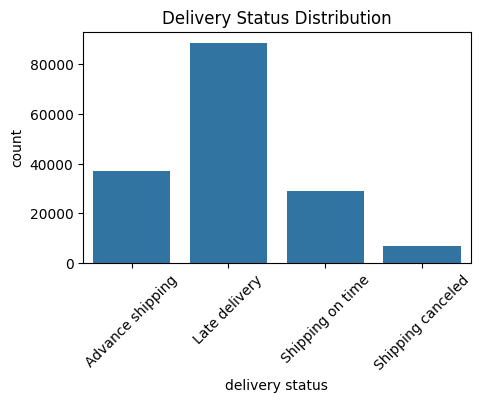

In [28]:
plt.figure(figsize=(5,3))
sns.countplot(x='Delivery Status',data=df)
plt.title("Delivery Status Distribution")
plt.xlabel("delivery status")
plt.xticks(rotation=45)
plt.show()

Late deliveries represent a significant portion of total orders, indicating operational inefficiencies in logistics and shipment management.

Top Countries with maximum delays

In [29]:
top_delays=(df.groupby('Order Country')['Delayed'].sum().sort_values(ascending=False).head(5))
top_delays

Order Country
Estados Unidos    12548
Francia            6717
Mxico             6431
Alemania           4837
Australia          4027
Name: Delayed, dtype: int64

Shipping Mode Performance

In [30]:
shipping_days=(df.groupby('Shipping Mode')['Delivery Days'].mean().sort_values(ascending=False))
shipping_days

Shipping Mode
Standard Class    8.744465
Second Class      5.876263
First Class      -2.701219
Same Day         -3.577979
Name: Delivery Days, dtype: float64

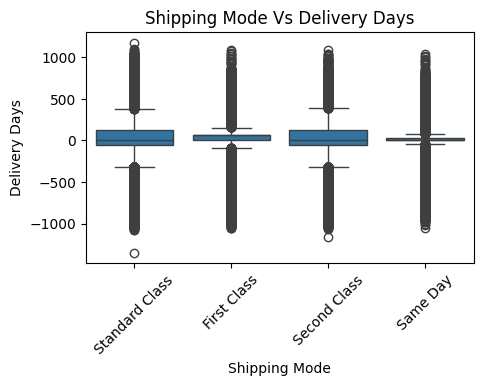

In [31]:
plt.figure(figsize=(5,3))
sns.boxplot(x='Shipping Mode',y='Delivery Days',data=df)
plt.title("Shipping Mode Vs Delivery Days")
plt.xticks(rotation=45)
plt.show()

Standard Class shipping shows higher average delivery times compared to premium shipping methods, suggesting a trade-off between cost and delivery speed.

Sales Performance by category

In [33]:
category_sales=(df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False))
category_sales

Category Name
Fishing                 6.242488e+06
Cleats                  3.791130e+06
Camping & Hiking        3.652557e+06
Cardio Equipment        3.172135e+06
Water Sports            3.113845e+06
Women's Apparel         2.719650e+06
Indoor/Outdoor Games    2.649290e+06
Men's Footwear          2.571722e+06
Shop By Sport           1.123897e+06
Computers               6.105000e+05
Electronics             3.213873e+05
Cameras                 2.413894e+05
Garden                  2.274117e+05
Children's Clothing     2.106890e+05
Crafts                  2.048971e+05
Girls' Apparel          1.315273e+05
Women's Clothing        1.243123e+05
Sporting Goods          1.170068e+05
Golf Gloves             1.166954e+05
Accessories             1.135046e+05
Golf Shoes              1.079980e+05
Consumer Electronics    9.735880e+04
Music                   9.487660e+04
Health and Beauty       9.406584e+04
Kids' Golf Clubs        8.699769e+04
Baseball & Softball     8.121979e+04
Boxing & MMA            

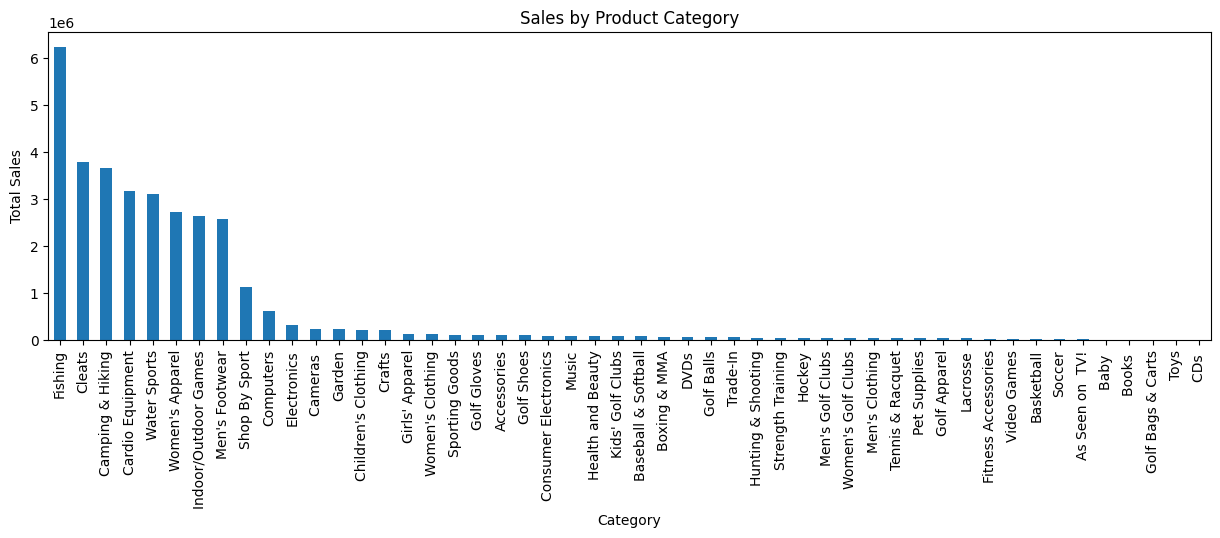

In [38]:
plt.figure(figsize=(15,4))
category_sales.plot(kind='bar')
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

A few product categories contribute heavily toward total revenue, indicating high-demand product segments.
Top 3 categories are Fishing,Cleats,Camping & Hiking

Profitability Analysis

In [41]:
profit_category=(df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False))
profit_category

Category Name
Fishing                 690977.106491
Cleats                  422317.700176
Camping & Hiking        376888.388191
Cardio Equipment        329723.428642
Water Sports            325146.960038
Women's Apparel         305439.489637
Indoor/Outdoor Games    291225.580528
Men's Footwear          276035.750179
Shop By Sport           112465.140284
Computers                63862.020039
Electronics              35186.419918
Garden                   30330.430084
Cameras                  26169.709942
Children's Clothing      24630.889591
Crafts                   24478.130060
Girls' Apparel           15695.809998
Women's Clothing         15483.529964
Music                    13278.609961
Accessories              13220.700069
Golf Gloves              12975.490078
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Consumer Electronics     12345.509957
Baseball & Softball      10323.540049
Health and Beauty         8516.089945
Boxing & MMA              8440.09001

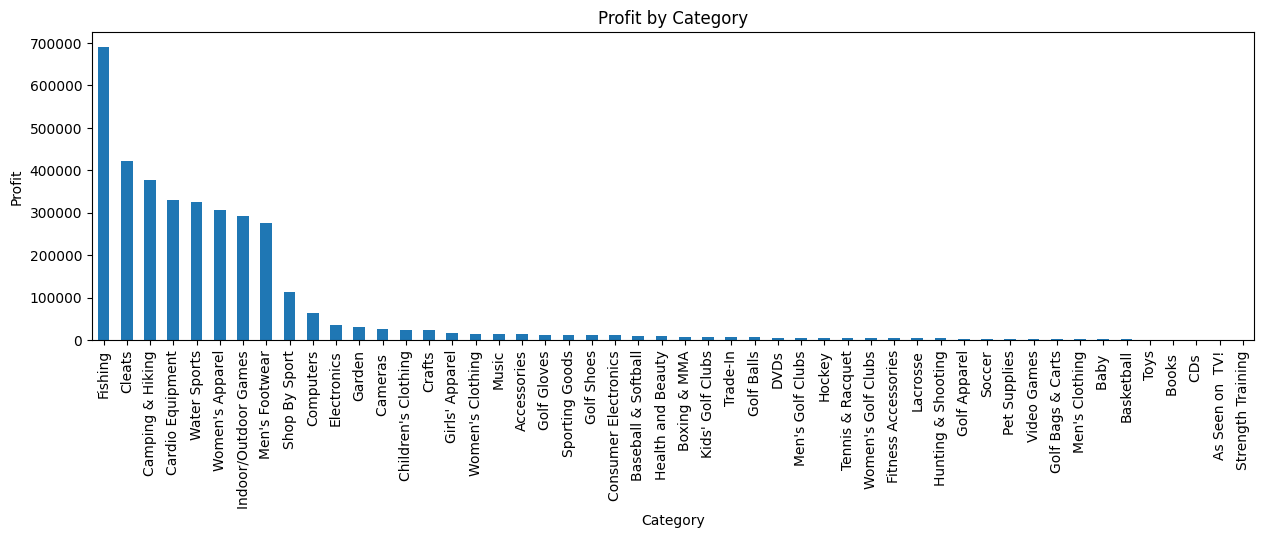

In [43]:
plt.figure(figsize=(15,4))
profit_category.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

Some categories generate strong sales but relatively lower profit margins, indicating pricing or operational cost issues.

Shipping cost Vs Profit

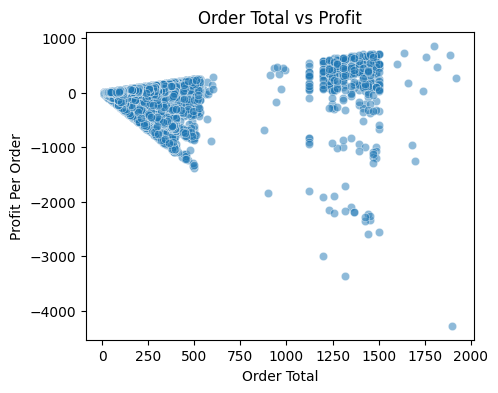

In [57]:
plt.figure(figsize=(5,4))

sns.scatterplot(x='Order Item Total',y='Order Profit Per Order',data=df,alpha=0.5)

plt.title("Order Total vs Profit")
plt.xlabel("Order Total")
plt.ylabel("Profit Per Order")

plt.show()

Higher order values generally contribute to increased profitability, although some high-value orders still generate low profit margins, indicating possible discounting or operational inefficiencies.

Monthly Sales Trend

In [58]:
monthly_sales=(df.groupby('Order Month')['Sales'].sum())
monthly_sales

Order Month
1     2.871251e+06
2     2.482323e+06
3     2.800970e+06
4     2.657629e+06
5     2.773754e+06
6     2.718362e+06
7     2.810940e+06
8     2.786433e+06
9     2.749129e+06
10    3.026511e+06
11    2.563993e+06
12    2.640414e+06
Name: Sales, dtype: float64

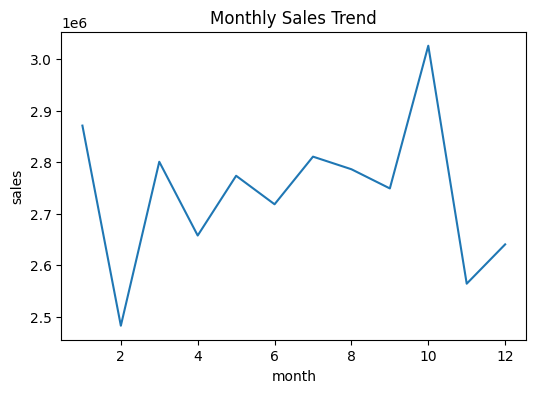

In [62]:
plt.figure(figsize=(6,4))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("month")
plt.ylabel("sales")
plt.show()

Sales fluctuate seasonally across months, indicating peak purchasing periods and demand cycles.